<a href="https://colab.research.google.com/github/jojimenezt/project-NLP/blob/main/Segunda_Entrega/Segunda_Entrega_Proyecto_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 📊 PREPROCESAMIENTO PLN DE ARCHIVO "Referencias OMIM.xlsx"
# ============================================================

# Instalación de librerías necesarias
!pip install spacy nltk wordcloud unidecode
!python -m spacy download en_core_web_sm

# ------------------------------------------------------------
# 1️⃣ IMPORTAR LIBRERÍAS
# ------------------------------------------------------------
import pandas as pd
import re
import nltk
import unidecode
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Descargar stopwords de NLTK
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 72.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# ------------------------------------------------------------
# CARGAR EL ARCHIVO
# ------------------------------------------------------------

file_path = "/content/Referencias OMIM.xlsx"  # cambia si tiene otro nombre
df = pd.read_excel(file_path)

# Verificamos las columnas
print("Columnas disponibles:")
print(df.columns)
print("\nPrimeras filas:")
display(df.head())

Columnas disponibles:
Index(['MIM number gen', 'Gen', 'ubicación', 'fenotipo', 'inherencia',
       'referencias', 'autor', 'titulo', 'abstract', 'año', 'PDF'],
      dtype='object')

Primeras filas:


,MIM number gen,Gen,ubicación,fenotipo,inherencia,referencias,autor,titulo,abstract,año,PDF
0,172411.0,PLA2G2A,1p36.13,cancer de colon,"AD, Smu",https://www.nature.com/articles/ng0997-88,"Robert T. Cormier, Karen H. Hong, Richard B. H...",Secretory phospholipase Pla2g2a confers resist...,Individuals inheriting the same mutation predi...,1997,NaN
1,NaN,NaN,NaN,NaN,NaN,https://www.cell.com/cell/pdf/0092-8674(93)904...,"William F. Dietrich,’ Eric S. Lander,’ \nJenni...","Genetic Identification of Mom-l, \na Major Mod...",Mutations in the human APC gene cause various ...,1993,NaN
2,NaN,NaN,NaN,NaN,NaN,https://link.springer.com/article/10.1007/s004...,"Zuzana Dobbie, Karl Heinimann, D. Tim Bishop, ...",Identification of a modifier gene locus on chr...,Phenotypic variability based on nonallelic het...,1997,NaN
3,NaN,NaN,NaN,NaN,NaN,https://www.nature.com/articles/ng0997-7,Tommaso A. Dragani & Giacomo Manenti,Mom1 leads the pack,,1997,NaN
4,NaN,NaN,NaN,NaN,NaN,https://gut.bmj.com/content/40/1/95,"M M Haapamäki, J M Grönroos, H Nurmi, K Alanen...",Gene expression of group II phospholipase A2 i...,It has been suggested that phospholipase A2 (P...,1997,NaN


#Prepocesamiento: Entendimiento y preparación del conjunto de texto

In [ ]:
# ------------------------------------------------------------
# COMBINAR LAS COLUMNAS RELEVANTES (titulo, abstract, autor)
# ------------------------------------------------------------
df["texto"] = (
    df["titulo"].fillna("") + " " +
    df["abstract"].fillna("") + " " +
    df["autor"].fillna("")
)

In [ ]:
# ------------------------------------------------------------
# LIMPIEZA DE TEXTO MEJORADA PARA DATOS GENÉTICOS
# ------------------------------------------------------------
def limpiar_texto_genetico(texto):
    texto = str(texto).lower()
    texto = unidecode.unidecode(texto)                      # quitar tildes pero preservar texto

    # Eliminar URLs pero preservar contenido genético
    texto = re.sub(r"http\S+|www\S+", "", texto)            # eliminar URLs

    # PRESERVAR elementos críticos para genética:
    # - Números y guiones en nombres de genes: PLA2G2A, BRCA-1
    # - Localizaciones cromosómicas: 1p36.13, chr17-q21
    # - Variantes: c.123A>T, p.Arg123Trp
    # - Números de acceso: NM_000546
    # - Marcadores: rs123456
    # - Dosis y medidas: 2.5-fold, 50%, p<0.05

    # Permitir: letras, números, guiones, puntos, símbolos matemáticos, paréntesis
    texto = re.sub(r"[^\w\s\.\-\>\<\(\)\=\%\/]", " ", texto)

    # Preservar guiones en contextos genéticos (entre letras-números)
    texto = re.sub(r"(\w)\s*-\s*(\w)", r"\1-\2", texto)     # unir guiones en términos genéticos

    # Preservar símbolos matemáticos importantes
    texto = re.sub(r"\s*>\s*", ">", texto)
    texto = re.sub(r"\s*<\s*", "<", texto)
    texto = re.sub(r"\s*=\s*", "=", texto)

    # Eliminar letras sueltas (pero preservar si son parte de términos genéticos)
    # No eliminar letras sueltas que puedan ser importantes en genética

    texto = re.sub(r"\s+", " ", texto).strip()              # quitar espacios extra
    return texto

df["texto_limpio"] = df["texto"].apply(limpiar_texto_genetico)
print("Texto antes y después de la limpieza mejorada:")
print(df[["texto", "texto_limpio"]].head(10))


Texto antes y después de la limpieza mejorada:
                                               texto  \
0  Secretory phospholipase Pla2g2a confers resist...   
1  Genetic Identification of Mom-l, \na Major Mod...   
2  Identification of a modifier gene locus on chr...   
3  Mom1 leads the pack   Tommaso A. Dragani & Gia...   
4  Gene expression of group II phospholipase A2 i...   
5  Phospholipase A2 group IIA expression in gastr...   
6  The Secretory Phospholipase A2 Gene Is a Candi...   
7  EcoRl and Nsil RFLPs at a human PLA2 gene on c...   
8  The Min (Multiple Intestinal Neoplasia) Mutati...   
9  ApcMin, a mutation in the murine Apc gene, pre...   

                                        texto_limpio  
0  secretory phospholipase pla2g2a confers resist...  
1  genetic identification of mom-l a major modifi...  
2  identification of a modifier gene locus on chr...  
3  mom1 leads the pack tommaso a. dragani giacomo...  
4  gene expression of group ii phospholipase a2 i...  
5  pho

In [ ]:
# ------------------------------------------------------------
# TOKENIZACIÓN MEJORADA PARA DATOS GENÉTICOS
# ------------------------------------------------------------
stop_words = set(stopwords.words("english"))

# Stopwords personalizados - EXCLUYENDO términos genéticos importantes
custom_stopwords = {
    "study", "analysis", "human", "cell", "tissue",
    "method", "result", "conclusion", "abstract", "background",
    "objective", "significant", "level", "group", "control",
    "material", "procedure", "finding", "observation",
    # Términos genéticos que SÍ debemos preservar:
    # "gene", "protein", "expression", "mutation", "chromosome",
    # "locus", "variant", "allele", "genotype", "phenotype"
}

def tokenizar_genetico(texto):
    # Primero: tokenización básica preservando términos especiales
    tokens = texto.split()

    # Segundo: extraer términos genéticos específicos con patrones
    patrones_geneticos = [
        r'\b[a-z]+\d+[a-z]*\b',                    # genes: pla2g2a, brca1
        r'\b\d+[pq]\d+\.?\d*\b',                   # localizaciones: 1p36.13
        r'\bchr\d+[pq]?\d*\.?\d*\b',               # cromosomas: chr1, chr17q21
        r'\b\d+\.\d+\b',                           # números decimales: 2.5, 0.05
        r'\b\w+-\w+\b',                            # términos con guiones
        r'\b\w+_\w+\b',                            # términos con underscores
        r'\b\w+\.\w+\b',                           # términos con puntos
        r'\b[acgtu]+\b',                           # secuencias de nucleótidos
        r'\b\d+[x×]\b',                            # multiplicaciones: 2x, 3-fold
        r'\b\w+>\w+\b',                            # variantes: c.123a>t
        r'\bp\.\w+\d+\w+\b',                       # variantes proteicas: p.arg123trp
    ]

    tokens_especiales = []
    for patron in patrones_geneticos:
        tokens_especiales.extend(re.findall(patron, texto))

    # Combinar tokens y filtrar stopwords (excluyendo términos genéticos importantes)
    todos_tokens = tokens + tokens_especiales
    tokens_filtrados = [
        w for w in todos_tokens
        if w not in stop_words
        and w not in custom_stopwords
        and len(w) > 1  # preservar términos de 2+ caracteres
    ]

    return list(set(tokens_filtrados))  # eliminar duplicados

df["tokens"] = df["texto_limpio"].apply(tokenizar_genetico)
print("\nTokens después de tokenización genética:")
print(df[["texto_limpio", "tokens"]].head(10))


Tokens después de tokenización genética:
                                        texto_limpio  \
0  secretory phospholipase pla2g2a confers resist...   
1  genetic identification of mom-l a major modifi...   
2  identification of a modifier gene locus on chr...   
3  mom1 leads the pack tommaso a. dragani giacomo...   
4  gene expression of group ii phospholipase a2 i...   
5  phospholipase a2 group iia expression in gastr...   
6  the secretory phospholipase a2 gene is a candi...   
7  ecorl and nsil rflps at a human pla2 gene on c...   
8  the min (multiple intestinal neoplasia) mutati...   
9  apcmin a mutation in the murine apc gene predi...   

                                              tokens  
0  [individuals, strong, represent, mulherkar, fa...  
1  [conservation, controls, score, heterozygosity...  
2  [score, markers, 1p35, dominantly, familial, h...  
3  [leads, a., pack, mom1, manenti, tommaso, drag...  
4  [synthesis, detected, metaplastic, northern, d...  
5  [lawP, i

In [ ]:
# ------------------------------------------------------------
# LEMATIZACIÓN Y STEMMING MEJORADO
# ------------------------------------------------------------
nlp = spacy.load("en_core_web_sm")
stemmer = PorterStemmer()

def lematizar_y_stem_genetico(tokens):
    # Unir tokens para procesar con spaCy
    texto_unido = " ".join(tokens)
    doc = nlp(texto_unido)

    lemmas = []
    for token in doc:
        # Preservar términos que parecen genéticos (números, guiones, etc.)
        if any(char.isdigit() or char in '-_.>=<' for char in token.text):
            lemmas.append(token.text)  # preservar original
        elif token.is_alpha:
            lemmas.append(token.lemma_)  # lematizar palabras normales

    # Stemming solo para palabras sin características genéticas
    stems = []
    for lemma in lemmas:
        if any(char.isdigit() or char in '-_.>=' for char in lemma):
            stems.append(lemma)  # preservar términos genéticos
        else:
            stems.append(stemmer.stem(lemma))  # aplicar stemming

    return stems

df["tokens_procesados"] = df["tokens"].apply(lematizar_y_stem_genetico)
print("\nTokens después de lematización/stemming genético:")
print(df[["tokens", "tokens_procesados"]].head(10))


Tokens después de lematización/stemming genético:
                                              tokens  \
0  [individuals, strong, represent, mulherkar, fa...   
1  [conservation, controls, score, heterozygosity...   
2  [score, markers, 1p35, dominantly, familial, h...   
3  [leads, a., pack, mom1, manenti, tommaso, drag...   
4  [synthesis, detected, metaplastic, northern, d...   
5  [lawP, intriguingpossibility, m., chuP, rui, p...   
6  [m., apcm-induced, homolog, familial, kelly, s...   
7  [second, pancreatic, exon, umesh, roger, sublo...   
8  [occupied, adenoma, hybrids, marker, penetrant...   
9  [mattes, m., sensitive, homolog, transplantati...   

                                   tokens_procesados  
0  [individu, strong, repres, mulherkar, famili, ...  
1  [conserv, control, score, heterozygos, famili,...  
2  [score, marker, 1p35, dominantli, famili, hete...  
3  [lead, a., pack, mom1, manenti, tommaso, draga...  
4  [synthesi, detect, metaplast, northern, diseas...  
5 

In [ ]:
# ------------------------------------------------------------
# ANÁLISIS DE TÉRMINOS GENÉTICOS ESPECÍFICOS
# ------------------------------------------------------------
def extraer_terminos_geneticos(tokens):
    """Extraer términos específicamente genéticos para análisis separado"""
    patrones_geneticos = {
        'genes': r'\b[a-z]+\d+[a-z]*\b',
        'localizaciones': r'\b\d+[pq]\d+\.?\d*\b',
        'cromosomas': r'\bchr\d+[pq]?\d*\.?\d*\b',
        'variantes': r'\b\w+>\w+\b|\bp\.\w+\d+\w+\b',
        'numeros_cientificos': r'\b\d+\.\d+\b',
        'marcadores': r'\brs\d+\b',
    }

    terminos_especificos = {}
    for categoria, patron in patrones_geneticos.items():
        encontrados = []
        for token in tokens:
            if re.match(patron, token, re.IGNORECASE):
                encontrados.append(token)
        terminos_especificos[categoria] = encontrados

    return terminos_especificos

# Aplicar a todo el dataset
df["terminos_geneticos"] = df["tokens_procesados"].apply(extraer_terminos_geneticos)

# Mostrar términos genéticos encontrados
print("\nTérminos genéticos encontrados en las primeras filas:")
for i, row in df.head(3).iterrows():
    print(f"\nFila {i}:")
    for categoria, terminos in row["terminos_geneticos"].items():
        if terminos:
            print(f"  {categoria}: {terminos}")



Términos genéticos encontrados en las primeras filas:

Fila 0:
  genes: ['mom1', 'gene2', 'mom1', 'phospholipase6', 'strain1', 'mapped4', 'background3', 'background3', 'phospholipase6']

Fila 1:

Fila 2:
  localizaciones: ['1p35', '1p35', '1p35']
  numeros_cientificos: ['2.08', '1.77']


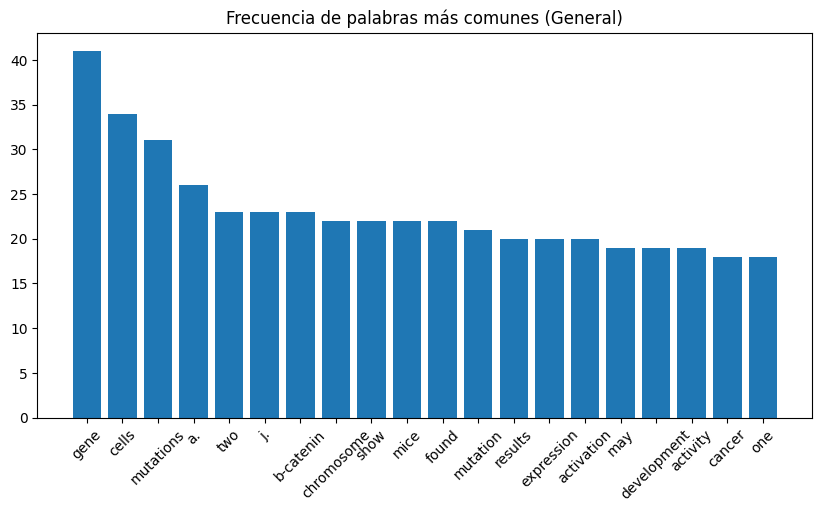

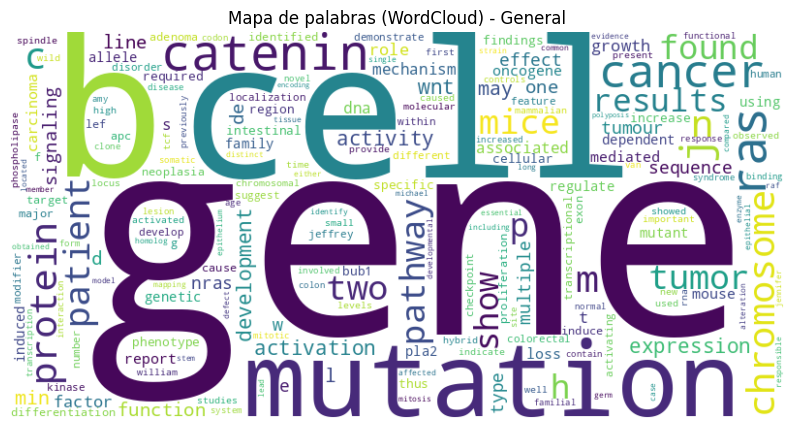

In [ ]:
# ------------------------------------------------------------
# FRECUENCIA GLOBAL DE PALABRAS
# ------------------------------------------------------------
todas_palabras = [p for tokens in df["tokens"] for p in tokens]
frecuencias = Counter(todas_palabras)
palabras_comunes = frecuencias.most_common(20)

# Gráfico de barras de frecuencia global
plt.figure(figsize=(10, 5))
plt.bar(*zip(*palabras_comunes))
plt.title("Frecuencia de palabras más comunes (General)")
plt.xticks(rotation=45)
plt.show()

# Nube de palabras general
wordcloud = WordCloud(
    width=800, height=400, background_color='white',
    collocations=False
).generate(" ".join(todas_palabras))

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Mapa de palabras (WordCloud) - General")
plt.show()

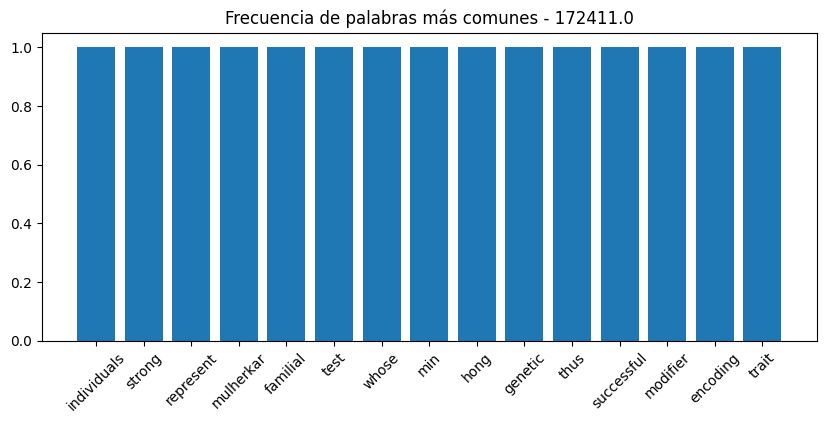

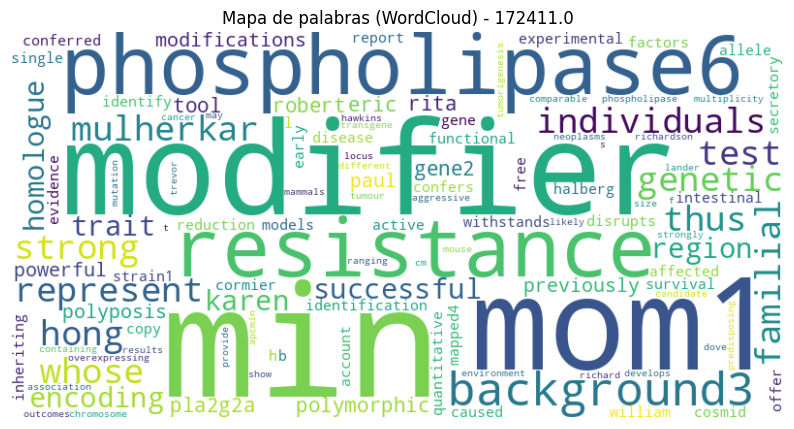

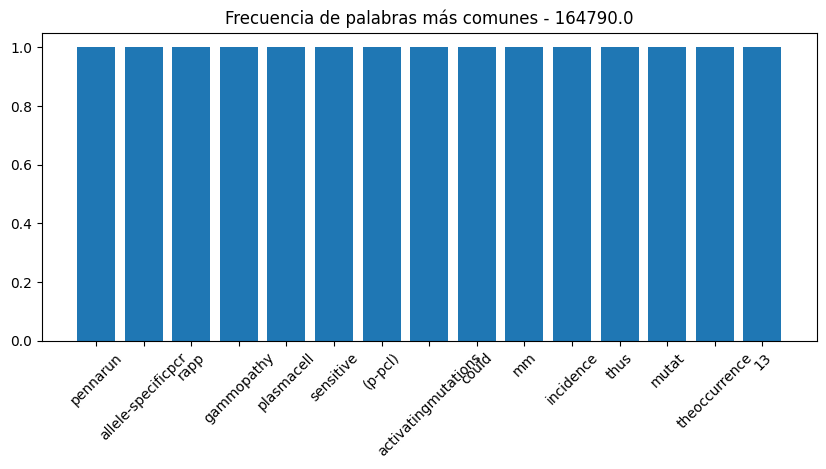

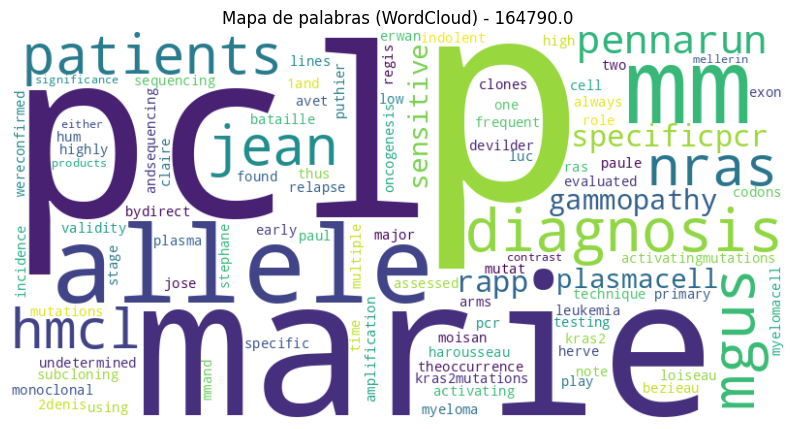

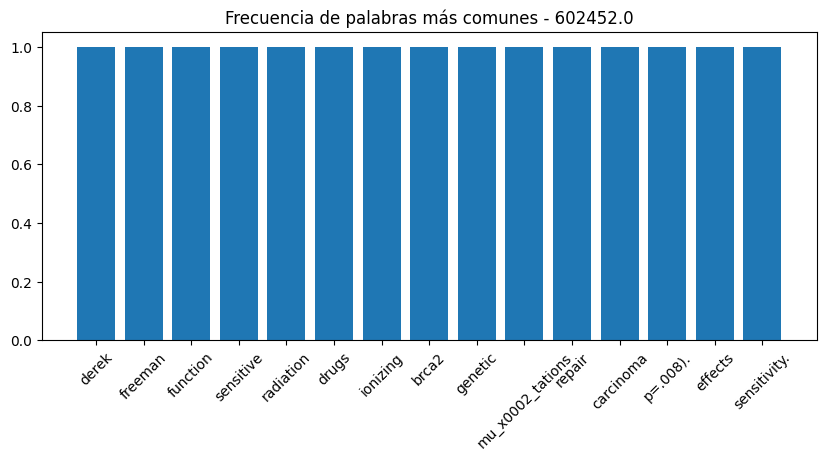

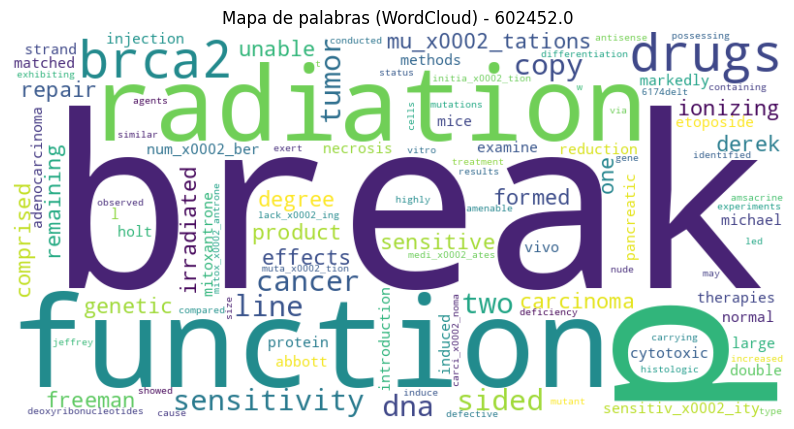

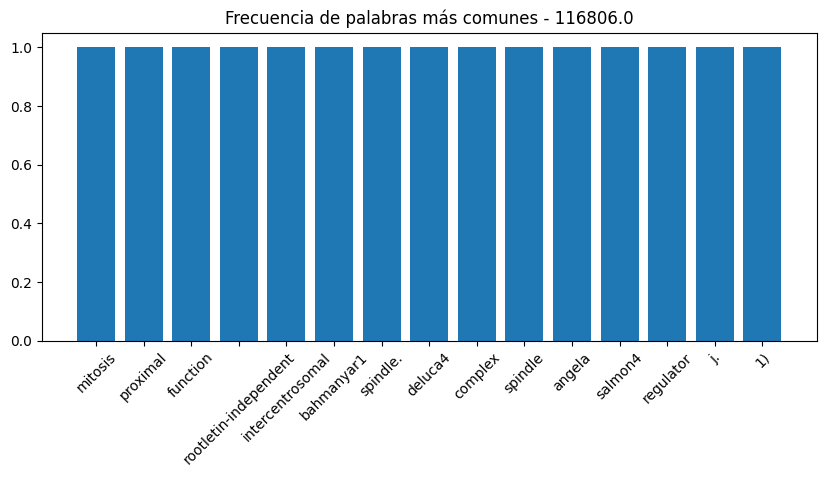

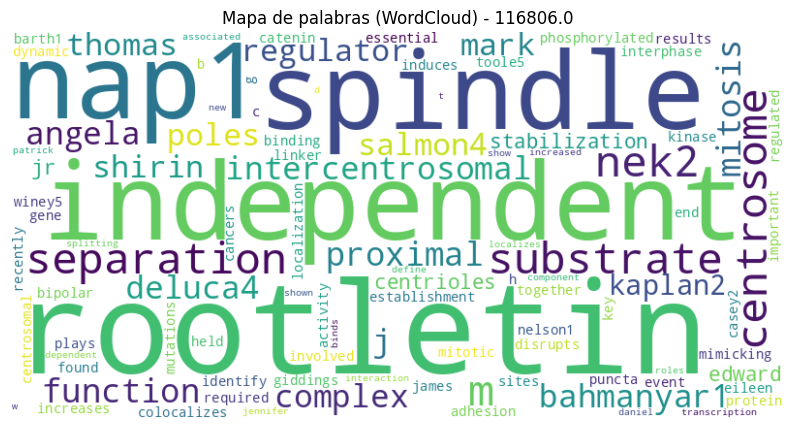

In [ ]:
# ------------------------------------------------------------
# ANÁLISIS POR GEN
# ------------------------------------------------------------
genes = df["MIM number gen"].unique()
resultados_gen = {}

for gen in genes:
    subset = df[df["MIM number gen"] == gen]
    palabras_gen = [p for tokens in subset["tokens"] for p in tokens]
    if not palabras_gen:
        continue

    frecuencias_gen = Counter(palabras_gen).most_common(15)
    resultados_gen[gen] = frecuencias_gen

    # Gráfico de barras por gen
    plt.figure(figsize=(10, 4))
    plt.bar(*zip(*frecuencias_gen))
    plt.title(f"Frecuencia de palabras más comunes - {gen}")
    plt.xticks(rotation=45)
    plt.show()

    # Nube de palabras por gen
    wordcloud_gen = WordCloud(
        width=800, height=400, background_color='white',
        collocations=False
    ).generate(" ".join(palabras_gen))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud_gen, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Mapa de palabras (WordCloud) - {gen}")
    plt.show()

In [ ]:
# ------------------------------------------------------------
# ANÁLISIS ESPECÍFICO DE TÉRMINOS GENÉTICOS
# ------------------------------------------------------------
# Extraer todos los términos genéticos por categoría
genes = []
localizaciones = []
cromosomas = []
variantes = []

for terminos_dict in df["terminos_geneticos"]:
    genes.extend(terminos_dict.get('genes', []))
    localizaciones.extend(terminos_dict.get('localizaciones', []))
    cromosomas.extend(terminos_dict.get('cromosomas', []))
    variantes.extend(terminos_dict.get('variantes', []))

print("\n--- ANÁLISIS DE TÉRMINOS GENÉTICOS ---")
print(f"Genes únicos encontrados: {len(set(genes))}")
print(f"Localizaciones únicas: {len(set(localizaciones))}")
print(f"Cromosomas mencionados: {len(set(cromosomas))}")
print(f"Variantes identificadas: {len(set(variantes))}")

# Mostrar los más comunes por categoría
if genes:
    print(f"\nGenes más comunes: {Counter(genes).most_common(10)}")
if localizaciones:
    print(f"Localizaciones más comunes: {Counter(localizaciones).most_common(10)}")
if cromosomas:
    print(f"Cromosomas mencionados: {Counter(cromosomas).most_common(10)}")

# ------------------------------------------------------------
# GUARDAR RESULTADOS MEJORADOS
# ------------------------------------------------------------
# Crear DataFrame con resultados
resultados_geneticos = df[[
    'Gen', 'fenotipo', 'texto_limpio', 'tokens_procesados', 'terminos_geneticos'
]].copy()

print("\nDataset procesado con información genética preservada:")
display(resultados_geneticos.head())



--- ANÁLISIS DE TÉRMINOS GENÉTICOS ---
Genes únicos encontrados: 248
Localizaciones únicas: 8
Cromosomas mencionados: 0
Variantes identificadas: 2

Genes más comunes: [('bub1', 12), ('pla2', 10), ('a2', 6), ('p21', 4), ('sgo1', 4), ('hrasg12v', 4), ('ctnnb1', 4), ('mom1', 3), ('pla2s', 3), ('rasg12d', 3)]
Localizaciones más comunes: [('1p35', 3), ('1p21', 2), ('1p11', 2), ('6p11', 2), ('12p11.1', 2), ('3p21', 2), ('1p22', 1), ('13q12.13', 1)]

Dataset procesado con información genética preservada:


,Gen,fenotipo,texto_limpio,tokens_procesados,terminos_geneticos
0,PLA2G2A,cancer de colon,secretory phospholipase pla2g2a confers resist...,"[individu, strong, repres, mulherkar, famili, ...","{'genes': ['mom1', 'gene2', 'mom1', 'phospholi..."
1,NaN,NaN,genetic identification of mom-l a major modifi...,"[conserv, control, score, heterozygos, famili,...","{'genes': [], 'localizaciones': [], 'cromosoma..."
2,NaN,NaN,identification of a modifier gene locus on chr...,"[score, marker, 1p35, dominantli, famili, hete...","{'genes': [], 'localizaciones': ['1p35', '1p35..."
3,NaN,NaN,mom1 leads the pack tommaso a. dragani giacomo...,"[lead, a., pack, mom1, manenti, tommaso, draga...","{'genes': ['mom1'], 'localizaciones': [], 'cro..."
4,NaN,NaN,gene expression of group ii phospholipase a2 i...,"[synthesi, detect, metaplast, northern, diseas...","{'genes': ['a2', 'pla2', 'pla2', 'pla2', 'pla2..."


##Transformación del texto para extracción de características

In [ ]:
# ==========================
# EXTRACCIÓN DE CARACTERÍSTICAS Y VECTORIZACIÓN
# ==========================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Volvemos a unir los tokens procesados en texto
df["texto_final"] = df["tokens_procesados"].apply(lambda x: " ".join(x))

# --------------------------
# Estrategia 1: Bag of Words (BoW)
# --------------------------
bow_vectorizer = CountVectorizer(max_features=1000)  # puedes ajustar el número de características
X_bow = bow_vectorizer.fit_transform(df["texto_final"])

# Mostrar las primeras palabras seleccionadas como features
print("🔹 Palabras seleccionadas (BoW):")
print(bow_vectorizer.get_feature_names_out()[:30])

# --------------------------
# Estrategia 2: TF-IDF
# --------------------------
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df["texto_final"])

print("\n🔹 Palabras seleccionadas (TF-IDF):")
print(tfidf_vectorizer.get_feature_names_out()[:30])

# Convertir a DataFrame para visualizar
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.head()


🔹 Palabras seleccionadas (BoW):
['10' '100' '11' '12' '13' '14' '15' '16' '17' '19' '1p35' '20' '2003'
 '21' '22' '23' '24' '27' '300' '36' '3b' '3p21' '50' '60' '61' '70' 'a2'
 'aberr' 'abil' 'abnorm']

🔹 Palabras seleccionadas (TF-IDF):
['10' '100' '11' '12' '13' '14' '15' '16' '17' '19' '1p35' '20' '2003'
 '21' '22' '23' '24' '27' '300' '36' '3b' '3p21' '50' '60' '61' '70' 'a2'
 'aberr' 'abil' 'abnorm']


,10,100,11,12,13,14,15,16,17,19,...,william,within,without,wnt,wnt8,yac,yang,yeast,young,yu
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.084936,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.092814,0.0,0.0,0.0,0.0,...,0.087150,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.093615,0.0,0.0,0.0,0.0,...,0.000000,0.085462,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.107799,0.0,0.0,0.0,0.0,0.0,0.0,0.0


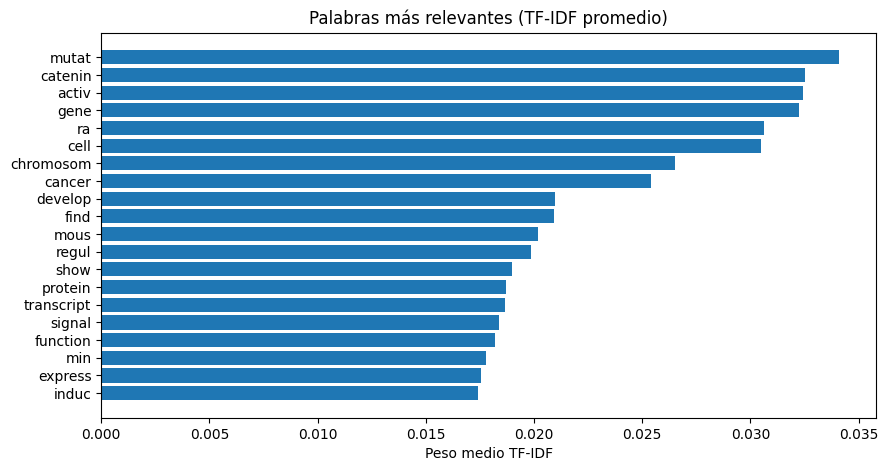

In [ ]:
# Promedio de importancia de cada palabra
import numpy as np
promedios = np.asarray(X_tfidf.mean(axis=0)).ravel()
palabras = tfidf_vectorizer.get_feature_names_out()

# Tomamos las 20 más relevantes
top_indices = promedios.argsort()[-20:][::-1]
plt.figure(figsize=(10,5))
plt.barh(np.array(palabras)[top_indices], promedios[top_indices])
plt.gca().invert_yaxis()
plt.title("Palabras más relevantes (TF-IDF promedio)")
plt.xlabel("Peso medio TF-IDF")
plt.show()


##Modelo de aprendizaje Supervisado

In [ ]:
# --------------------------
# Crear dataset de entrenamiento NER
# --------------------------

# Crear la columna 'texto_ner' combinando título, abstract y autor
df["texto_ner"] = (
    df["titulo"].fillna('') + ". " +
    df["abstract"].fillna('') + ". " +
    df["autor"].fillna('')
)

TRAIN_DATA = []

for _, row in df.iterrows():
    texto = row["texto_ner"]
    gen = str(row["MIM number gen"]).strip()

    # Buscar la posición del gen en el texto
    if gen and gen.lower() in texto.lower():
        start = texto.lower().find(gen.lower())
        end = start + len(gen)
        TRAIN_DATA.append((texto, {"entities": [(start, end, "GENE")]}))


In [ ]:
# --------------------------
# Entrenamiento del modelo NER (spaCy)
# --------------------------

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
import random

# Crear modelo base en inglés
nlp = spacy.blank("en")

# Crear pipeline de NER
ner = nlp.add_pipe("ner")

# Agregar etiquetas
ner.add_label("GENE")

# Entrenamiento
optimizer = nlp.begin_training()

for itn in range(20):
    random.shuffle(TRAIN_DATA)
    losses = {}
    batches = minibatch(TRAIN_DATA, size=compounding(4.0, 32.0, 1.001))
    for batch in batches:
        texts, annotations = zip(*batch)
        examples = [Example.from_dict(nlp.make_doc(t), a) for t, a in zip(texts, annotations)]
        nlp.update(examples, drop=0.3, losses=losses)
    print(f"Iteración {itn+1} - Pérdida: {losses['ner']:.4f}")


/usr/local/lib/python3.12/dist-packages/spacy/training/iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "The Secretory Phospholipase A2 Gene Is a Candidate..." with entities "[(251, 254, 'GENE')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/spacy/training/iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Specific Pattern of RAS Oncogene Mutations in
Foll..." with entities "[(166, 169, 'GENE')]". Use `spacy.training.offsets_to_biluo_tags(nlp.make_doc(text), entities)` to check the alignment. Misaligned entities ('-') will be ignored during training.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/spacy/training/iob_utils.py:149: UserWarning: [W030] Some entities could not be aligned in the text "Genotypic and Gene Expression Studies in Cong

Iteración 1 - Pérdida: 4088.6772
Iteración 2 - Pérdida: 991.4349
Iteración 3 - Pérdida: 0.6247
Iteración 4 - Pérdida: 0.0000
Iteración 5 - Pérdida: 0.0000
Iteración 6 - Pérdida: 0.0000
Iteración 7 - Pérdida: 0.0000
Iteración 8 - Pérdida: 0.0000
Iteración 9 - Pérdida: 0.0000
Iteración 10 - Pérdida: 0.0000
Iteración 11 - Pérdida: 0.0000
Iteración 12 - Pérdida: 0.0000
Iteración 13 - Pérdida: 0.0000
Iteración 14 - Pérdida: 0.0000
Iteración 15 - Pérdida: 0.0000
Iteración 16 - Pérdida: 0.0000
Iteración 17 - Pérdida: 0.0000
Iteración 18 - Pérdida: 0.0000
Iteración 19 - Pérdida: 0.0000
Iteración 20 - Pérdida: 0.0000


In [ ]:
# --------------------------
# Guardar el modelo entrenado
# -------------------------

nlp.to_disk("modelo_genes")

# Cargar modelo entrenado
modelo_genes = spacy.load("modelo_genes")

# Probar en nuevo texto
texto_prueba = "Recent studies identified mutations in TP53 and BRCA2 genes."
doc = modelo_genes(texto_prueba)

print("🧬 Entidades encontradas:")
for ent in doc.ents:
    print(ent.text, ent.label_)


🧬 Entidades encontradas:


**Análisis de metricas cientificas**

🔬 APLICANDO ANÁLISIS CIENTÍFICAMENTE RELEVANTES...


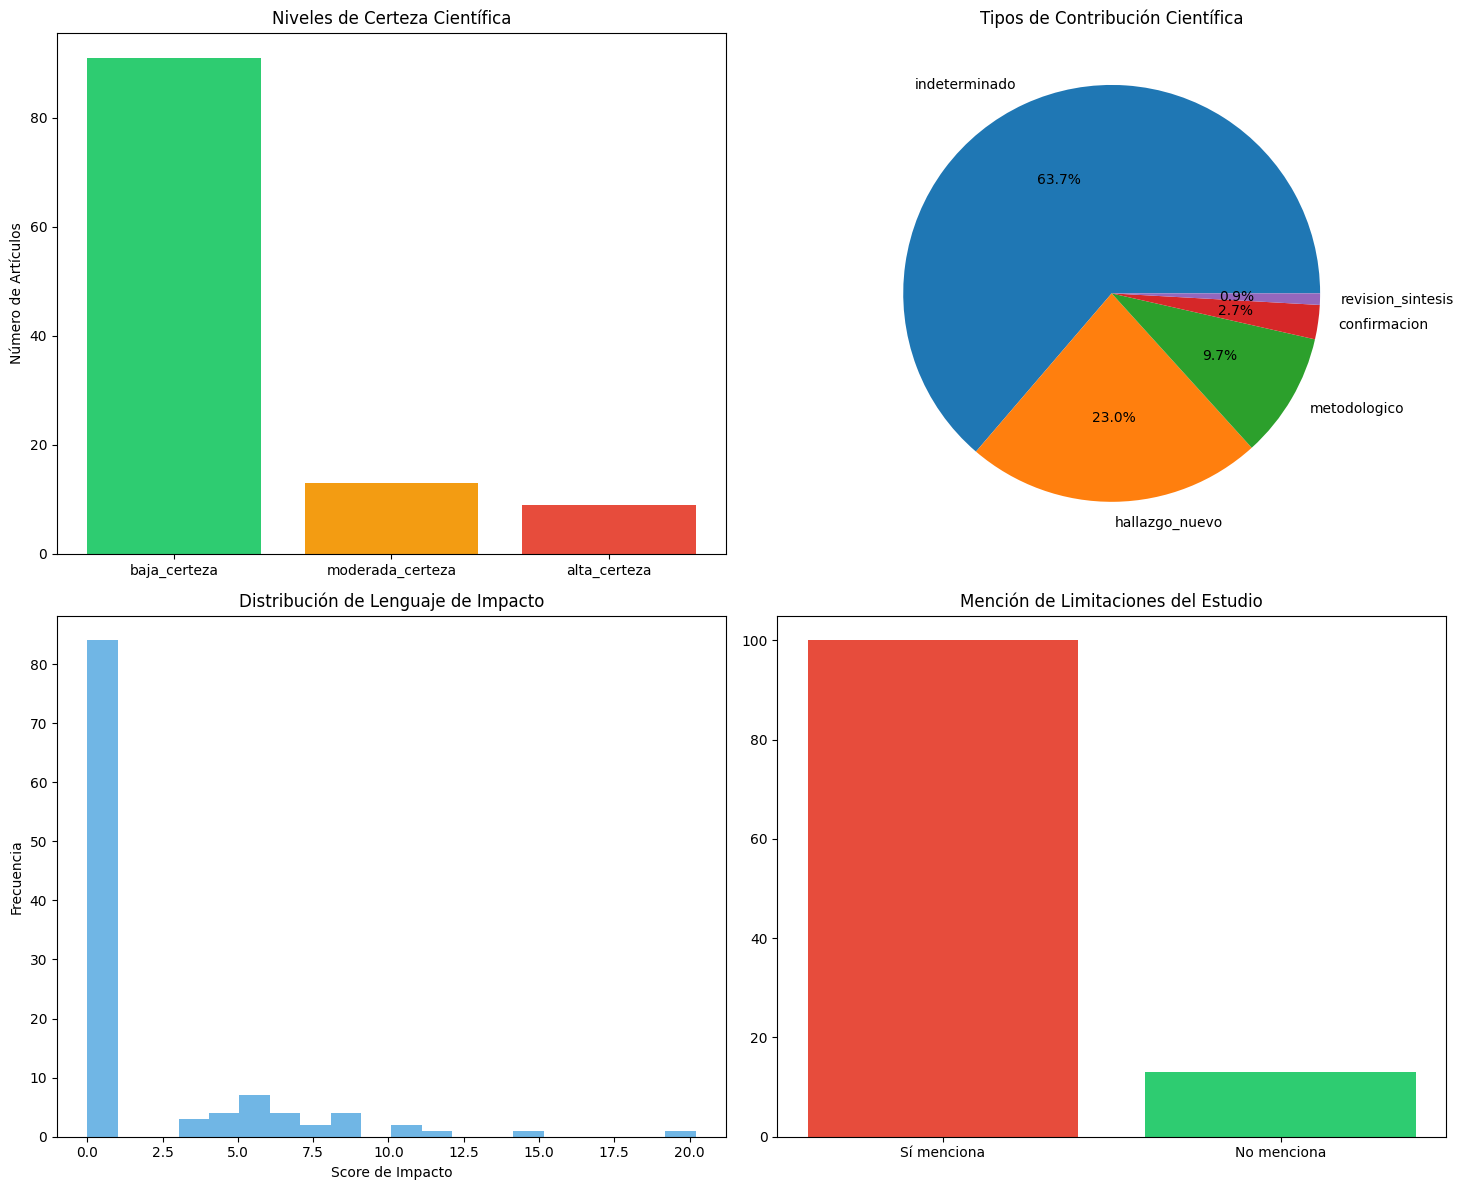


📈 EVOLUCIÓN TEMPORAL DE MÉTRICAS CIENTÍFICAS:
      score_impacto  menciona_limitaciones  porcentaje_limitaciones
año                                                                
1982          0.000                  0.000                      0.0
1983          4.866                  0.000                      0.0
1984          4.132                  0.000                      0.0
1985          0.000                  0.000                      0.0
1988          0.000                  0.000                      0.0
1989          3.575                  0.333                     33.3
1990          0.000                  0.000                      0.0
1992          1.634                  0.500                     50.0
1993          5.319                  0.000                      0.0
1995          5.748                  0.000                      0.0
1997          0.000                  0.167                     16.7
1998          6.579                  0.000                      0.0
1

In [ ]:
# ------------------------------------------------------------
# ANÁLISIS
# ------------------------------------------------------------

# 1. ANÁLISIS DE CERTEZA/CONFIANZA CIENTÍFICA
def analizar_certeza_cientifica(texto):
    """
    Analiza el grado de certeza/confianza en los hallazgos
    """
    indicadores_certeza = {
        'alta_certeza': [
            r'\bconfirm\b', r'\bdemonstrate\b', r'\bestablish\b', r'\bprove\b',
            r'\bdefinitively\b', r'\bclear evidence\b', r'\bconclusive\b',
            r'\bsignificant\b', r'\bp\s*<\s*0\.05\b', r'\bstrongly\b'
        ],
        'moderada_certeza': [
            r'\bsuggest\b', r'\bindicate\b', r'\bpropose\b', r'\bimply\b',
            r'\bconsistent with\b', r'\bappear to\b', r'\btend to\b'
        ],
        'baja_certeza': [
            r'\bmay\b', r'\bmight\b', r'\bcould\b', r'\bpossibly\b',
            r'\bpotential\b', r'\bspeculate\b', r'\bhypothesize\b'
        ]
    }

    texto = texto.lower()
    resultados = {}

    for nivel, patrones in indicadores_certeza.items():
        count = 0
        for patron in patrones:
            count += len(re.findall(patron, texto))
        resultados[nivel] = count

    # Determinar nivel predominante
    if resultados['alta_certeza'] > resultados['moderada_certeza'] + resultados['baja_certeza']:
        nivel_predominante = "alta_certeza"
    elif resultados['moderada_certeza'] > resultados['baja_certeza']:
        nivel_predominante = "moderada_certeza"
    else:
        nivel_predominante = "baja_certeza"

    resultados['nivel_predominante'] = nivel_predominante
    return resultados

# 2. ANÁLISIS DE CONTRIBUCION CIENTÍFICA
def analizar_tipo_contribucion(texto):
    """
    Clasifica el tipo de contribución científica
    """
    categorias = {
        'hallazgo_nuevo': [
            r'\bnovel\b', r'\bnew\b', r'\bfirst\b', r'\bpreviously unknown\b',
            r'\bunreported\b', r'\bdiscover\b', r'\bidentify\b'
        ],
        'confirmacion': [
            r'\bconfirm\b', r'\bvalidate\b', r'\breplicate\b', r'\bconsistent with\b',
            r'\bsupport\b', r'\bagree with\b'
        ],
        'metodologico': [
            r'\bmethod\b', r'\btechnique\b', r'\bapproach\b', r'\bprotocol\b',
            r'\bassay\b', r'\banalysis\b'
        ],
        'revision_sintesis': [
            r'\breview\b', r'\bsummarize\b', r'\boverview\b', r'\bmeta.analysis\b',
            r'\bsystematic\b'
        ]
    }

    texto = texto.lower()
    scores = {}

    for categoria, patrones in categorias.items():
        score = 0
        for patron in patrones:
            score += len(re.findall(patron, texto))
        scores[categoria] = score

    # Categoría predominante
    cat_predominante = max(scores.items(), key=lambda x: x[1])
    return {
        'scores': scores,
        'contribucion_principal': cat_predominante[0] if cat_predominante[1] > 0 else 'indeterminado'
    }

# 3. ANÁLISIS DE IMPACTO POTENCIAL
def analizar_impacto_potencial(texto):
    """
    Evalúa lenguaje que indica potencial impacto/importancia
    """
    indicadores_impacto = [
        r'\bimportant\b', r'\bsignificant\b', r'\bcritical\b', r'\bkey\b',
        r'\bcrucial\b', r'\bbreakthrough\b', r'\badvance\b', r'\bmajor\b',
        r'\bsubstantial\b', r'\bprofound\b', r'\btransformative\b'
    ]

    texto = texto.lower()
    count_impacto = 0

    for patron in indicadores_impacto:
        count_impacto += len(re.findall(patron, texto))

    # Normalizar por longitud del texto
    longitud = len(texto.split())
    score_normalizado = (count_impacto / longitud * 1000) if longitud > 0 else 0

    return {
        'count_impacto': count_impacto,
        'score_impacto': round(score_normalizado, 3),
        'nivel_impacto': 'alto' if score_normalizado > 1.0 else 'moderado' if score_normalizado > 0.5 else 'bajo'
    }

# 4. ANÁLISIS DE LIMITACIONES
def analizar_limitaciones(texto):
    """
    Identifica discusión de limitaciones del estudio
    """
    indicadores_limitaciones = [
        r'\blimit\b', r'\bconstraint\b', r'\bcaveat\b', r'\bshortcoming\b',
        r'\bhowever\b', r'\balthough\b', r'\bdespite\b', r'\bfurther studies\b',
        r'\bfuture work\b', r'\badditional research\b'
    ]

    texto = texto.lower()
    count_limitations = sum(len(re.findall(patron, texto)) for patron in indicadores_limitaciones)

    return {
        'menciona_limitaciones': count_limitations > 0,
        'count_limitaciones': count_limitations
    }

# APLICAR ANÁLISIS ALTERNATIVOS
print("🔬 APLICANDO ANÁLISIS CIENTÍFICAMENTE RELEVANTES...")

df["analisis_certeza"] = df["texto_limpio"].apply(analizar_certeza_cientifica)
df["analisis_contribucion"] = df["texto_limpio"].apply(analizar_tipo_contribucion)
df["analisis_impacto"] = df["texto_limpio"].apply(analizar_impacto_potencial)
df["analisis_limitaciones"] = df["texto_limpio"].apply(analizar_limitaciones)

# Extraer métricas para análisis
df["nivel_certeza"] = df["analisis_certeza"].apply(lambda x: x["nivel_predominante"])
df["tipo_contribucion"] = df["analisis_contribucion"].apply(lambda x: x["contribucion_principal"])
df["score_impacto"] = df["analisis_impacto"].apply(lambda x: x["score_impacto"])
df["menciona_limitaciones"] = df["analisis_limitaciones"].apply(lambda x: x["menciona_limitaciones"])

# ------------------------------------------------------------
# VISUALIZACIONES MÁS APROPIADAS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Distribución de niveles de certeza
certeza_count = df["nivel_certeza"].value_counts()
axes[0, 0].bar(certeza_count.index, certeza_count.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0, 0].set_title('Niveles de Certeza Científica')
axes[0, 0].set_ylabel('Número de Artículos')

# Gráfico 2: Tipos de contribución
contribucion_count = df["tipo_contribucion"].value_counts()
axes[0, 1].pie(contribucion_count.values, labels=contribucion_count.index, autopct='%1.1f%%')
axes[0, 1].set_title('Tipos de Contribución Científica')

# Gráfico 3: Distribución de scores de impacto
axes[1, 0].hist(df["score_impacto"], bins=20, alpha=0.7, color='#3498db')
axes[1, 0].set_xlabel('Score de Impacto')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Lenguaje de Impacto')

# Gráfico 4: Artículos que mencionan limitaciones
limitaciones_count = df["menciona_limitaciones"].value_counts()
axes[1, 1].bar(['Sí menciona', 'No menciona'], limitaciones_count.values, color=['#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Mención de Limitaciones del Estudio')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ANÁLISIS TEMPORAL DE MÉTRICAS CIENTÍFICAS
# ------------------------------------------------------------
def analisis_temporal_cientifico(df):
    """Análisis de cómo evolucionan las métricas científicas por año"""

    # --- Limpieza del campo 'año' ---
    df_temp = df.copy()
    df_temp["año"] = (
        df_temp["año"]
        .astype(str)       # Convierte todo a string
        .str.strip()       # Elimina espacios al inicio y final
        .replace("", None) # Reemplaza cadenas vacías por NaN
    )

    # Convierte a número, los errores se vuelven NaN
    df_temp["año"] = pd.to_numeric(df_temp["año"], errors="coerce")

    # Filtra solo los años válidos (numéricos)
    df_temp = df_temp.dropna(subset=["año"])
    df_temp["año"] = df_temp["año"].astype(int)

    # --- Análisis por año ---
    analisis = df_temp.groupby("año").agg({
        "score_impacto": "mean",
        "menciona_limitaciones": "mean",  # Porcentaje que menciona limitaciones
    }).round(3)

    # Calcula el porcentaje
    analisis["porcentaje_limitaciones"] = (analisis["menciona_limitaciones"] * 100).round(1)

    return analisis

analisis_temporal_ciencia = analisis_temporal_cientifico(df)
print("\n📈 EVOLUCIÓN TEMPORAL DE MÉTRICAS CIENTÍFICAS:")
print(analisis_temporal_ciencia)

# ------------------------------------------------------------
# RESUMEN MEJORADO
# ------------------------------------------------------------
def resumen_analisis_cientifico(df):
    print("=" * 70)
    print("RESUMEN DE ANÁLISIS CIENTÍFICAMENTE RELEVANTE")
    print("=" * 70)

    print(f"\n🔍 CERTEZA CIENTÍFICA:")
    distrib_certeza = df["nivel_certeza"].value_counts()
    for nivel, count in distrib_certeza.items():
        print(f"   • {nivel.replace('_', ' ').title()}: {count} artículos")

    print(f"\n🎯 TIPOS DE CONTRIBUCIÓN:")
    distrib_contrib = df["tipo_contribucion"].value_counts()
    for tipo, count in distrib_contrib.items():
        print(f"   • {tipo.replace('_', ' ').title()}: {count} artículos")

    print(f"\n💡 IMPACTO CIENTÍFICO:")
    print(f"   • Score de impacto promedio: {df['score_impacto'].mean():.3f}")
    print(f"   • Artículos con alto impacto: {(df['score_impacto'] > 1.0).sum()}")

    print(f"\n⚠️  RIGOR CIENTÍFICO:")
    print(f"   • Artículos que mencionan limitaciones: {df['menciona_limitaciones'].sum()} ({df['menciona_limitaciones'].mean()*100:.1f}%)")

resumen_analisis_cientifico(df)

 **Aprendizaje no supervizado**

🧹 Limpiando y preparando datos...
   • Textos válidos (≥50 chars): 84/113
   • Años válidos: 73/113
   • Autores no nulos: 84/113
🔬 INICIANDO ANÁLISIS DE APRENDIZAJE NO SUPERVISADO...
🚀 INICIANDO ANÁLISIS DE APRENDIZAJE NO SUPERVISADO
🧹 Limpiando y preparando datos...
   • Textos válidos (≥50 chars): 84/113
   • Años válidos: 73/113
   • Autores no nulos: 84/113

──────────────────────────────────────────────────
🔍 Ejecutando K-means clustering de documentos...
   • Matriz de características: 84 documentos, 1000 términos
✅ K-means completado. Score de Silueta: 0.039


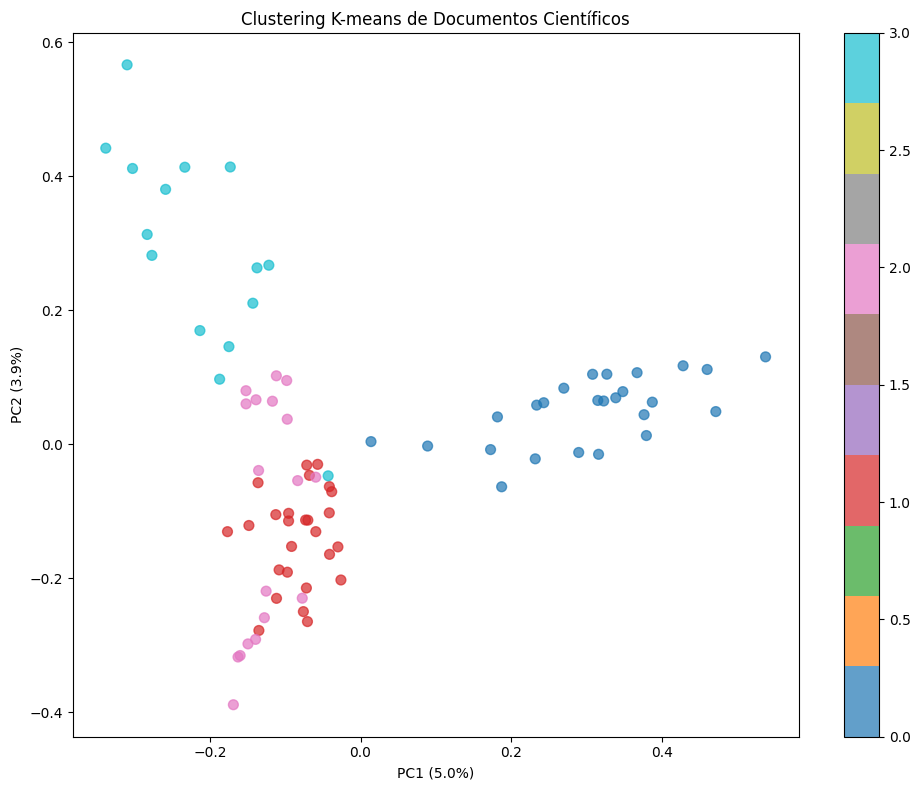


🔤 TÉRMINOS CLAVE POR CLUSTER (Top 10):
📁 Cluster 0:
   catenin, wnt, cell, cells, signaling, hair, ctnnb1, activation

📁 Cluster 1:
   bub1, human, checkpoint, chromosome, genes, cancer, pla2, phospholipase

📁 Cluster 2:
   nras, mutation, min, multiple, mutations, intestinal, gene, tumor

📁 Cluster 3:
   ras, human, follicular, gene, family, mutations, ras ras, ras gene


──────────────────────────────────────────────────
🔍 Ejecutando clustering jerárquico...
   • Muestreando 50 de 84 documentos
✅ Clustering jerárquico completado. Clusters: 5


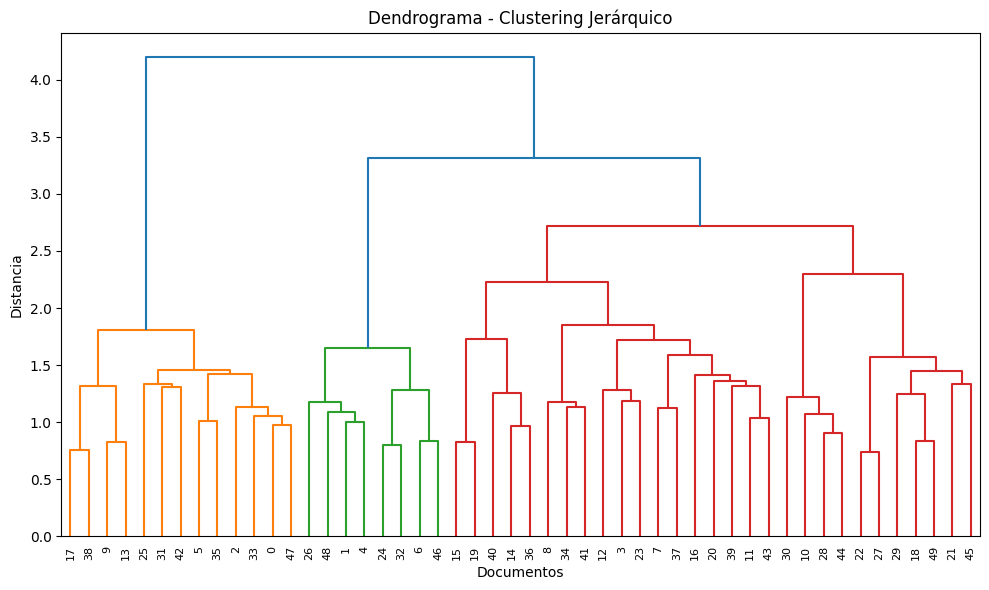


──────────────────────────────────────────────────
🔍 Analizando similitud entre autores...
📊 Analizando 622 autores activos...
✅ Análisis de autores completado. Score de Silueta: 0.134

──────────────────────────────────────────────────
🔍 Analizando tendencias temporales...
   • Rango temporal: 1982 - 2016
📊 Analizando 7 períodos temporales...

📊 RESUMEN DE APRENDIZAJE NO SUPERVISADO

✅ CLUSTERING DE DOCUMENTOS (K-means):
   • Número de clusters: 4
   • Score de Silueta: 0.039
   • Score Calinski-Harabasz: 3.0
   • Distribución: {0.0: np.int64(25), 1.0: np.int64(26), 2.0: np.int64(18), 3.0: np.int64(15)}

✅ CLUSTERING JERÁRQUICO:
   • Clusters identificados: 5
   • Documentos analizados: 50

✅ CLUSTERING DE AUTORES:
   • Autores analizados: 622
   • Clusters identificados: 4
   • Score de Silueta: 0.134

✅ ANÁLISIS TEMPORAL:
   • Períodos analizados: 7
   • Tendencias identificadas: 3

📈 EFECTIVIDAD: 4/4 técnicas ejecutadas exitosamente

✅ Resultados exportados a: resultados_no_superv

In [ ]:
# ============================================================
# 🔍 ANÁLISIS DE APRENDIZAJE NO SUPERVISADO PARA DATOS GENÉTICOS
# ============================================================

# ------------------------------------------------------------
# PREPROCESAMIENTO Y LIMPIEZA DE DATOS
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import re
from collections import Counter

def limpiar_y_preparar_datos(df):
    """
    Limpia y prepara los datos para el análisis no supervisado
    """
    print("🧹 Limpiando y preparando datos...")

    df_clean = df.copy()

    # 1. Limpiar columna 'año'
    def limpiar_año(valor):
        if pd.isna(valor):
            return np.nan
        try:
            # Convertir a string y limpiar
            str_valor = str(valor).strip()
            # Extraer solo números
            numeros = re.findall(r'\d+', str_valor)
            if numeros:
                año = int(numeros[0])
                # Validar rango razonable para años científicos
                if 1900 <= año <= 2030:
                    return año
            return np.nan
        except (ValueError, TypeError):
            return np.nan

    df_clean['año_limpio'] = df_clean['año'].apply(limpiar_año)

    # 2. Asegurar que texto_limpio sea string
    df_clean['texto_limpio'] = df_clean['texto_limpio'].fillna('').astype(str)

    # 3. Filtrar textos muy cortos
    longitud_minima = 50  # caracteres
    mask_texto_valido = df_clean['texto_limpio'].str.len() >= longitud_minima
    print(f"   • Textos válidos (≥{longitud_minima} chars): {mask_texto_valido.sum()}/{len(df_clean)}")

    # 4. Informe de limpieza
    print(f"   • Años válidos: {df_clean['año_limpio'].notna().sum()}/{len(df_clean)}")
    print(f"   • Autores no nulos: {df_clean['autor'].notna().sum()}/{len(df_clean)}")

    return df_clean

# Aplicar limpieza
df_clean = limpiar_y_preparar_datos(df)

# ------------------------------------------------------------
# 1. CLUSTERING DE DOCUMENTOS (K-means) - NO SUPERVISADO
# ------------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score

def clustering_documentos_kmeans(df, n_clusters=5, max_features=1000):
    """
    Clustering no supervisado de documentos científicos usando K-means
    """
    print("🔍 Ejecutando K-means clustering de documentos...")

    # Filtrar documentos válidos
    documentos_validos = df["texto_limpio"][df["texto_limpio"].str.len() >= 50]
    if len(documentos_validos) < n_clusters:
        print(f"⚠️  No hay suficientes documentos para {n_clusters} clusters")
        n_clusters = max(2, len(documentos_validos) - 1)
        print(f"   • Usando {n_clusters} clusters")

    if len(documentos_validos) < 2:
        print("❌ No hay suficientes documentos válidos para clustering")
        return None

    # Vectorización TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words='english',
        min_df=2,  # Términos que aparecen en al menos 2 documentos
        max_df=0.8,  # Términos que aparecen en máximo 80% de documentos
        ngram_range=(1, 2)  # Unigramas y bigramas
    )

    try:
        # Crear matriz de características
        X = vectorizer.fit_transform(documentos_validos)

        print(f"   • Matriz de características: {X.shape[0]} documentos, {X.shape[1]} términos")

        # Aplicar K-means (NO SUPERVISADO)
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
        clusters = kmeans.fit_predict(X)

        # Evaluar calidad del clustering
        if len(set(clusters)) > 1:
            silhouette_avg = silhouette_score(X, clusters)
            # Convertir a array denso para Calinski-Harabasz
            X_dense = X.toarray() if hasattr(X, 'toarray') else X
            calinski_harabasz = calinski_harabasz_score(X_dense, clusters)
        else:
            silhouette_avg = 0
            calinski_harabasz = 0
            print("⚠️  Solo un cluster encontrado")

        resultados = {
            'clusters': clusters,
            'kmeans': kmeans,
            'vectorizer': vectorizer,
            'X': X,
            'documentos_indices': documentos_validos.index,
            'metricas': {
                'silhouette_score': silhouette_avg,
                'calinski_harabasz_score': calinski_harabasz,
                'n_clusters': n_clusters
            }
        }

        print(f"✅ K-means completado. Score de Silueta: {silhouette_avg:.3f}")
        return resultados

    except Exception as e:
        print(f"❌ Error en K-means: {e}")
        return None

# ------------------------------------------------------------
# 2. CLUSTERING JERÁRQUICO - NO SUPERVISADO
# ------------------------------------------------------------
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

def clustering_jerarquico_documentos(df, max_documentos=50):
    """
    Clustering jerárquico aglomerativo de documentos
    """
    print("🔍 Ejecutando clustering jerárquico...")

    # Filtrar documentos válidos
    documentos_validos = df["texto_limpio"][df["texto_limpio"].str.len() >= 50]

    if len(documentos_validos) < 3:
        print("⚠️  No hay suficientes documentos para clustering jerárquico")
        return None

    # Muestrear documentos para evitar sobrecarga computacional
    if len(documentos_validos) > max_documentos:
        documentos_muestra = documentos_validos.sample(max_documentos, random_state=42)
        print(f"   • Muestreando {max_documentos} de {len(documentos_validos)} documentos")
    else:
        documentos_muestra = documentos_validos
        print(f"   • Analizando {len(documentos_muestra)} documentos")

    # Vectorización
    vectorizer = TfidfVectorizer(
        max_features=300,  # Reducido para eficiencia
        stop_words='english',
        min_df=1,  # Más permisivo para muestra pequeña
        max_df=0.9
    )

    try:
        X = vectorizer.fit_transform(documentos_muestra)

        if X.shape[0] < 2:
            print("❌ Matriz de características muy pequeña")
            return None

        # Calcular matriz de distancia (cosine similarity)
        from sklearn.metrics.pairwise import cosine_similarity
        try:
            distancias = 1 - cosine_similarity(X)
        except:
            # Fallback: usar distancia euclidiana
            from sklearn.metrics.pairwise import euclidean_distances
            distancias = euclidean_distances(X.toarray())

        # Clustering jerárquico
        Z = linkage(distancias, 'ward')

        # Determinar clusters óptimos (método simplificado)
        optimal_clusters = min(5, max(2, X.shape[0] // 10))

        # Asignar clusters
        clusters = fcluster(Z, optimal_clusters, criterion='maxclust')

        resultados = {
            'linkage_matrix': Z,
            'clusters': clusters,
            'documentos_muestra': documentos_muestra.index,
            'optimal_clusters': optimal_clusters,
            'vectorizer': vectorizer,
            'X': X
        }

        print(f"✅ Clustering jerárquico completado. Clusters: {optimal_clusters}")
        return resultados

    except Exception as e:
        print(f"❌ Error en clustering jerárquico: {e}")
        return None

# ------------------------------------------------------------
# 3. ANÁLISIS DE SIMILITUD ENTRE AUTORES - NO SUPERVISADO
# ------------------------------------------------------------
def analisis_similitud_autores(df, min_publicaciones=1):
    """
    Análisis de similitud y clustering entre autores basado en términos que usan
    """
    print("🔍 Analizando similitud entre autores...")

    # Agrupar textos por autor
    textos_por_autor = {}
    for idx, row in df.dropna(subset=['autor']).iterrows():
        if pd.isna(row['autor']) or row['autor'] == '':
            continue

        try:
            autores = [a.strip() for a in str(row['autor']).split(',')]
            for autor in autores:
                if len(autor) > 3 and autor != 'et al':  # Filtrar nombres válidos
                    if autor not in textos_por_autor:
                        textos_por_autor[autor] = []
                    textos_por_autor[autor].append(row['texto_limpio'])
        except Exception as e:
            continue

    # Filtrar autores con suficientes publicaciones
    autores_activos = {autor: ' '.join(textos) for autor, textos in textos_por_autor.items()
                      if len(textos) >= min_publicaciones and len(' '.join(textos)) >= 100}

    if len(autores_activos) < 2:
        print("⚠️  No hay suficientes autores con publicaciones")
        return None

    print(f"📊 Analizando {len(autores_activos)} autores activos...")

    # Vectorización
    vectorizer = TfidfVectorizer(
        max_features=200,
        stop_words='english',
        min_df=1
    )

    try:
        X_autores = vectorizer.fit_transform(autores_activos.values())

        # Determinar número óptimo de clusters
        n_clusters_opt = min(4, max(2, len(autores_activos) // 3))

        # Clustering de autores (NO SUPERVISADO)
        kmeans_autores = KMeans(n_clusters=n_clusters_opt, random_state=42, n_init=10)
        clusters_autores = kmeans_autores.fit_predict(X_autores)

        # Calcular métricas de calidad
        if n_clusters_opt > 1 and len(set(clusters_autores)) > 1:
            silhouette_avg = silhouette_score(X_autores, clusters_autores)
        else:
            silhouette_avg = 0

        resultados = {
            'autores': list(autores_activos.keys()),
            'clusters': clusters_autores,
            'vectorizer': vectorizer,
            'kmeans': kmeans_autores,
            'X_autores': X_autores,
            'silhouette_score': silhouette_avg
        }

        print(f"✅ Análisis de autores completado. Score de Silueta: {silhouette_avg:.3f}")
        return resultados

    except Exception as e:
        print(f"❌ Error en análisis de autores: {e}")
        return None

# ------------------------------------------------------------
# 4. DETECCIÓN DE TENDENCIAS TEMPORALES - NO SUPERVISADO
# ------------------------------------------------------------
from sklearn.manifold import TSNE

def deteccion_tendencias_temporales(df, ventana_años=5):
    """
    Detección no supervisada de tendencias y evolución temporal
    """
    print("🔍 Analizando tendencias temporales...")

    # Usar la columna de año limpia
    df_temp = df[df["año_limpio"].notna()].copy()

    if len(df_temp) < 3:
        print("⚠️  No hay suficientes datos temporales")
        return None

    # Agrupar por períodos temporales
    periodos = {}
    año_min = int(df_temp["año_limpio"].min())
    año_max = int(df_temp["año_limpio"].max())

    print(f"   • Rango temporal: {año_min} - {año_max}")

    for año_inicio in range(año_min, año_max + 1, ventana_años):
        año_fin = min(año_inicio + ventana_años - 1, año_max)
        periodo_key = f"{año_inicio}-{año_fin}"

        textos_periodo = df_temp[
            (df_temp["año_limpio"] >= año_inicio) & (df_temp["año_limpio"] <= año_fin)
        ]["texto_limpio"].tolist()

        # Filtrar textos muy cortos
        textos_periodo = [t for t in textos_periodo if len(str(t)) >= 50]

        if len(textos_periodo) >= 2:  # Al menos 2 documentos por período
            periodos[periodo_key] = ' '.join(textos_periodo)

    if len(periodos) < 2:
        print("⚠️  No hay suficientes períodos para análisis")
        return None

    print(f"📊 Analizando {len(periodos)} períodos temporales...")

    try:
        # Análisis de similitud entre períodos (NO SUPERVISADO)
        vectorizer = TfidfVectorizer(max_features=150)
        X_periodos = vectorizer.fit_transform(periodos.values())

        # Reducción dimensional para visualización
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(periodos)-1))
        coords = tsne.fit_transform(X_periodos.toarray())

        # Clustering de períodos
        n_clusters = min(3, len(periodos))
        kmeans_periodos = KMeans(n_clusters=n_clusters, random_state=42)
        clusters_periodos = kmeans_periodos.fit_predict(X_periodos)

        return {
            'periodos': list(periodos.keys()),
            'coordenadas': coords,
            'clusters': clusters_periodos,
            'vectorizer': vectorizer,
            'kmeans': kmeans_periodos
        }
    except Exception as e:
        print(f"❌ Error en análisis temporal: {e}")
        return None

# ------------------------------------------------------------
# 5. ANÁLISIS DE TÉRMINOS POR CLUSTER
# ------------------------------------------------------------
def analizar_terminos_por_cluster(resultados_clustering, n_palabras=10):
    """
    Analiza las palabras más importantes por cluster descubierto
    """
    if resultados_clustering is None:
        return

    vectorizer = resultados_clustering['vectorizer']
    kmeans = resultados_clustering['kmeans']

    try:
        feature_names = vectorizer.get_feature_names_out()
    except AttributeError:
        feature_names = vectorizer.get_feature_names()

    print(f"\n🔤 TÉRMINOS CLAVE POR CLUSTER (Top {n_palabras}):")
    print("=" * 60)

    for cluster_id in range(kmeans.n_clusters):
        # Obtener centroide del cluster
        centroide = kmeans.cluster_centers_[cluster_id]

        # Ordenar términos por importancia en el centroide
        top_indices = centroide.argsort()[-n_palabras:][::-1]
        top_palabras = [feature_names[i] for i in top_indices if i < len(feature_names)]

        # Filtrar términos relevantes (eliminar stopwords simples)
        stopwords_simples = {'the', 'and', 'for', 'with', 'that', 'this', 'from', 'were', 'have', 'has', 'had'}
        terminos_relevantes = [palabra for palabra in top_palabras
                             if palabra not in stopwords_simples and len(palabra) > 2]

        print(f"📁 Cluster {cluster_id}:")
        if terminos_relevantes:
            print(f"   {', '.join(terminos_relevantes[:8])}")
        else:
            print(f"   No se encontraron términos distintivos")
        print()

# ------------------------------------------------------------
# 6. VISUALIZACIONES DE CLUSTERING
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

def visualizar_clusters_simple(resultados_clustering, titulo="Clustering de Documentos"):
    """
    Visualización simple de clusters para evitar errores
    """
    if resultados_clustering is None:
        return

    try:
        X = resultados_clustering['X']
        clusters = resultados_clustering['clusters']

        # Solo visualizar si tenemos al menos 2 dimensiones
        if X.shape[0] < 3:
            print("⚠️  No hay suficientes puntos para visualización")
            return

        # Usar PCA para visualización
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2, random_state=42)

        # Convertir a array denso si es sparse
        if hasattr(X, 'toarray'):
            X_dense = X.toarray()
        else:
            X_dense = X

        coords_pca = pca.fit_transform(X_dense)

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(coords_pca[:, 0], coords_pca[:, 1],
                            c=clusters, cmap='tab10', alpha=0.7, s=50)
        plt.colorbar(scatter)
        plt.title(titulo)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️  Error en visualización: {e}")

def visualizar_dendrograma_simple(resultados_jerarquico):
    """
    Visualiza el dendrograma del clustering jerárquico (versión simple)
    """
    if resultados_jerarquico is None:
        return

    try:
        Z = resultados_jerarquico['linkage_matrix']

        plt.figure(figsize=(10, 6))
        dendrogram(Z, orientation='top',
                  leaf_rotation=90, leaf_font_size=8)
        plt.title('Dendrograma - Clustering Jerárquico')
        plt.xlabel('Documentos')
        plt.ylabel('Distancia')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️  Error visualizando dendrograma: {e}")

# ------------------------------------------------------------
# 7. EJECUCIÓN COMPLETA DEL ANÁLISIS NO SUPERVISADO
# ------------------------------------------------------------
def ejecutar_analisis_no_supervisado_completo(df):
    """
    Ejecuta todas las técnicas de aprendizaje no supervisado con manejo de errores
    """
    print("=" * 70)
    print("🚀 INICIANDO ANÁLISIS DE APRENDIZAJE NO SUPERVISADO")
    print("=" * 70)

    # Primero limpiar los datos
    df_clean = limpiar_y_preparar_datos(df)

    resultados = {}

    # 1. Clustering de documentos con K-means
    print("\n" + "─" * 50)
    resultados['kmeans_documentos'] = clustering_documentos_kmeans(df_clean, n_clusters=4)

    if resultados['kmeans_documentos']:
        # Agregar clusters al DataFrame original
        indices_validos = resultados['kmeans_documentos']['documentos_indices']
        clusters = resultados['kmeans_documentos']['clusters']

        # Inicializar columna con NaN
        df_clean.loc[:, 'cluster_kmeans'] = np.nan
        df_clean.loc[indices_validos, 'cluster_kmeans'] = clusters

        # Visualizar clusters
        visualizar_clusters_simple(resultados['kmeans_documentos'],
                                 "Clustering K-means de Documentos Científicos")

        # Análisis de términos por cluster
        analizar_terminos_por_cluster(resultados['kmeans_documentos'])

    # 2. Clustering jerárquico
    print("\n" + "─" * 50)
    resultados['jerarquico'] = clustering_jerarquico_documentos(df_clean)
    if resultados['jerarquico']:
        visualizar_dendrograma_simple(resultados['jerarquico'])

    # 3. Análisis de similitud entre autores
    print("\n" + "─" * 50)
    resultados['autores'] = analisis_similitud_autores(df_clean)

    # 4. Detección de tendencias temporales
    print("\n" + "─" * 50)
    resultados['tendencias'] = deteccion_tendencias_temporales(df_clean)

    return resultados, df_clean

# ------------------------------------------------------------
# 8. RESUMEN DE RESULTADOS NO SUPERVISADOS
# ------------------------------------------------------------
def generar_resumen_no_supervisado(resultados, df):
    """
    Genera un resumen completo de los resultados del aprendizaje no supervisado
    """
    print("\n" + "=" * 70)
    print("📊 RESUMEN DE APRENDIZAJE NO SUPERVISADO")
    print("=" * 70)

    total_tecnicas = 0
    tecnicas_exitosas = 0

    if resultados.get('kmeans_documentos'):
        total_tecnicas += 1
        tecnicas_exitosas += 1
        metricas = resultados['kmeans_documentos']['metricas']
        print(f"\n✅ CLUSTERING DE DOCUMENTOS (K-means):")
        print(f"   • Número de clusters: {metricas['n_clusters']}")
        print(f"   • Score de Silueta: {metricas['silhouette_score']:.3f}")
        print(f"   • Score Calinski-Harabasz: {metricas['calinski_harabasz_score']:.1f}")

        # Distribución de clusters
        if 'cluster_kmeans' in df.columns:
            distrib = df['cluster_kmeans'].value_counts().sort_index()
            print(f"   • Distribución: {dict(distrib)}")
    else:
        print(f"\n❌ CLUSTERING DE DOCUMENTOS: No se pudo ejecutar")
        total_tecnicas += 1

    if resultados.get('jerarquico'):
        total_tecnicas += 1
        tecnicas_exitosas += 1
        print(f"\n✅ CLUSTERING JERÁRQUICO:")
        print(f"   • Clusters identificados: {resultados['jerarquico']['optimal_clusters']}")
        print(f"   • Documentos analizados: {len(resultados['jerarquico']['documentos_muestra'])}")
    else:
        print(f"\n❌ CLUSTERING JERÁRQUICO: No se pudo ejecutar")
        total_tecnicas += 1

    if resultados.get('autores'):
        total_tecnicas += 1
        tecnicas_exitosas += 1
        print(f"\n✅ CLUSTERING DE AUTORES:")
        print(f"   • Autores analizados: {len(resultados['autores']['autores'])}")
        print(f"   • Clusters identificados: {len(set(resultados['autores']['clusters']))}")
        print(f"   • Score de Silueta: {resultados['autores']['silhouette_score']:.3f}")
    else:
        print(f"\n❌ CLUSTERING DE AUTORES: No se pudo ejecutar")
        total_tecnicas += 1

    if resultados.get('tendencias'):
        total_tecnicas += 1
        tecnicas_exitosas += 1
        print(f"\n✅ ANÁLISIS TEMPORAL:")
        print(f"   • Períodos analizados: {len(resultados['tendencias']['periodos'])}")
        print(f"   • Tendencias identificadas: {len(set(resultados['tendencias']['clusters']))}")
    else:
        print(f"\n❌ ANÁLISIS TEMPORAL: No se pudo ejecutar")
        total_tecnicas += 1

    print(f"\n📈 EFECTIVIDAD: {tecnicas_exitosas}/{total_tecnicas} técnicas ejecutadas exitosamente")

# ------------------------------------------------------------
# EJECUTAR ANÁLISIS NO SUPERVISADO COMPLETO
# ------------------------------------------------------------
print("🔬 INICIANDO ANÁLISIS DE APRENDIZAJE NO SUPERVISADO...")

# Ejecutar todas las técnicas
resultados_no_supervisado, df_final = ejecutar_analisis_no_supervisado_completo(df)

# Generar resumen
generar_resumen_no_supervisado(resultados_no_supervisado, df_final)

# ------------------------------------------------------------
# EXPORTAR RESULTADOS NO SUPERVISADOS
# ------------------------------------------------------------
def exportar_resultados_no_supervisado(df, resultados, nombre_archivo="resultados_no_supervisado.xlsx"):
    """
    Exporta los resultados del aprendizaje no supervisado
    """
    try:
        # Crear DataFrame para exportación
        df_export = df.copy()

        # Seleccionar columnas relevantes
        columnas_export = []

        # Agregar columnas si existen
        if 'cluster_kmeans' in df_export.columns:
            columnas_export.append('cluster_kmeans')

        if 'texto_limpio' in df_export.columns:
            columnas_export.append('texto_limpio')

        if 'año_limpio' in df_export.columns:
            columnas_export.append('año_limpio')

        # Columnas base
        columnas_base = ['titulo', 'autor', 'año']
        for col in columnas_base:
            if col in df_export.columns:
                columnas_export.append(col)

        # Filtrar columnas existentes
        columnas_existentes = [col for col in columnas_export if col in df_export.columns]
        df_export_final = df_export[columnas_existentes]

        # Exportar
        df_export_final.to_excel(nombre_archivo, index=False)
        print(f"\n✅ Resultados exportados a: {nombre_archivo}")

        return True

    except Exception as e:
        print(f"\n❌ Error al exportar resultados: {e}")
        return False

# Exportar resultados
exportar_resultados_no_supervisado(df_final, resultados_no_supervisado)

print("\n" + "=" * 70)
print("🎉 ANÁLISIS NO SUPERVISADO COMPLETADO")
print("=" * 70)